In [1]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset path
train_dir = "/kaggle/input/tuberculosisdaata/TB_Data/Train"
val_dir = "/kaggle/input/tuberculosisdaata/TB_Data/Validation"
test_dir = "/kaggle/input/tuberculosisdaata/TB_Data/Test"


In [2]:
img_size = 224

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes


In [4]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=30):
    model.to(device)
    best_model = model.state_dict()
    best_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()

        val_acc = evaluate(model, val_loader)
        print(f"Epoch {epoch+1}: Train Acc: {correct/len(train_loader.dataset):.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model.state_dict()

    model.load_state_dict(best_model)
    return model

def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
    return correct / len(loader.dataset)


In [5]:
convnext_model = models.convnext_tiny(weights=None)
convnext_model.classifier[2] = nn.Linear(convnext_model.classifier[2].in_features, 2)
convnext_criterion = nn.CrossEntropyLoss()
convnext_optimizer = torch.optim.Adam(convnext_model.parameters(), lr=1e-4)

convnext_model = train_model(convnext_model, convnext_criterion, convnext_optimizer, train_loader, val_loader)


Epoch 1/30: 100%|██████████| 175/175 [03:03<00:00,  1.05s/it]


Epoch 1: Train Acc: 0.8186, Val Acc: 0.8929


Epoch 2/30: 100%|██████████| 175/175 [02:45<00:00,  1.06it/s]


Epoch 2: Train Acc: 0.8945, Val Acc: 0.9171


Epoch 3/30: 100%|██████████| 175/175 [02:45<00:00,  1.06it/s]


...

Epoch 28: Train Acc: 0.9827, Val Acc: 0.9771


Epoch 29/30: 100%|██████████| 175/175 [02:44<00:00,  1.06it/s]


Epoch 29: Train Acc: 0.9891, Val Acc: 0.9900


Epoch 30/30: 100%|██████████| 175/175 [02:45<00:00,  1.06it/s]


Epoch 30: Train Acc: 0.9875, Val Acc: 0.9886


In [6]:
vit_model = models.vit_b_16(weights=None)
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, 2)
vit_criterion = nn.CrossEntropyLoss()
vit_optimizer = torch.optim.Adam(vit_model.parameters(), lr=1e-4)
vit_model = train_model(vit_model, vit_criterion, vit_optimizer, train_loader, val_loader)


Epoch 1/30: 100%|██████████| 175/175 [02:28<00:00,  1.18it/s]


Epoch 1: Train Acc: 0.8348, Val Acc: 0.8700


Epoch 2/30: 100%|██████████| 175/175 [02:28<00:00,  1.18it/s]


Epoch 2: Train Acc: 0.9175, Val Acc: 0.9271


Epoch 3/30: 100%|██████████| 175/175 [02:29<00:00,  1.17it/s]


...

Epoch 28: Train Acc: 0.9711, Val Acc: 0.9686


Epoch 29/30: 100%|██████████| 175/175 [02:28<00:00,  1.18it/s]


Epoch 29: Train Acc: 0.9714, Val Acc: 0.9529


Epoch 30/30: 100%|██████████| 175/175 [02:28<00:00,  1.18it/s]


Epoch 30: Train Acc: 0.9768, Val Acc: 0.9700


In [7]:
def ensemble_predict(model1, model2, loader):
    all_labels, all_preds, all_probs = [], [], []
    softmax = nn.Softmax(dim=1)

    model1.eval()
    model2.eval()

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Ensemble Predict"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs1 = softmax(model1(inputs))
            outputs2 = softmax(model2(inputs))

            avg_outputs = (outputs1 + outputs2) / 2
            _, preds = torch.max(avg_outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(avg_outputs[:, 1].cpu().numpy())  # Probability for class 1

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [8]:
# Run ensemble prediction
labels, preds, probs = ensemble_predict(convnext_model, vit_model, test_loader)

# Evaluation metrics
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(labels, preds))
print("\nClassification Report:\n", classification_report(labels, preds, target_names=class_names))


Ensemble Predict: 100%|██████████| 22/22 [00:14<00:00,  1.51it/s]

Accuracy: 0.9857142857142858

Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       350
Tuberculosis       0.99      0.98      0.99       350

    accuracy                           0.99       700
   macro avg       0.99      0.99      0.99       700
weighted avg       0.99      0.99      0.99       700



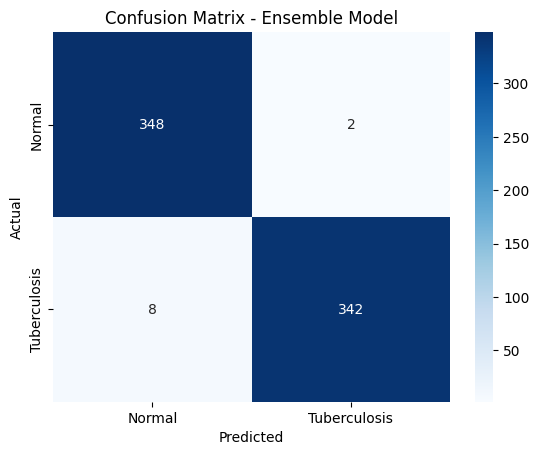

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble Model")
plt.show()


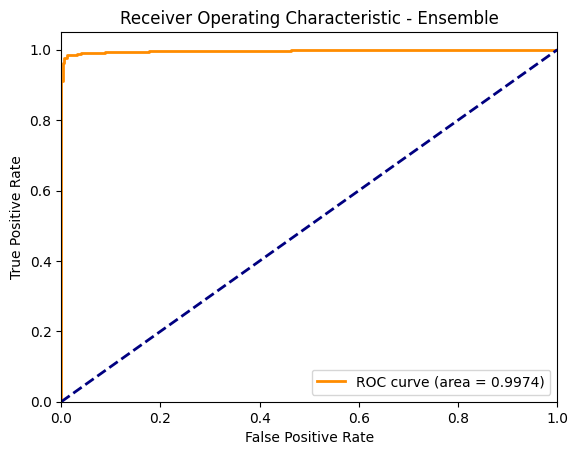

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Ensemble')
plt.legend(loc="lower right")
plt.show()


In [12]:
def evaluate(model, loader, criterion):
    model.eval()
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
            total_loss += loss.item()

    accuracy = correct / len(loader.dataset)
    avg_loss = total_loss / len(loader)
    return accuracy, avg_loss


In [13]:
labels, preds, probs = ensemble_predict(convnext_model, vit_model, test_loader)


Ensemble Predict: 100%|██████████| 22/22 [00:10<00:00,  2.05it/s]


In [14]:
# ConvNeXt
convnext_train_acc, _ = evaluate(convnext_model, train_loader, convnext_criterion)
convnext_val_acc, _ = evaluate(convnext_model, val_loader, convnext_criterion)

# ViT
vit_train_acc, _ = evaluate(vit_model, train_loader, vit_criterion)
vit_val_acc, _ = evaluate(vit_model, val_loader, vit_criterion)

# Ensemble Test Accuracy
labels, preds, probs = ensemble_predict(convnext_model, vit_model, test_loader)
from sklearn.metrics import accuracy_score
ensemble_test_acc = accuracy_score(labels, preds)

# Print Accuracies
print(f"\n🔢 Accuracy Summary:")
print(f"ConvNeXt - Train Accuracy: {convnext_train_acc*100:.2f}%")
print(f"ConvNeXt - Val Accuracy:   {convnext_val_acc*100:.2f}%")
print(f"ViT       - Train Accuracy: {vit_train_acc*100:.2f}%")
print(f"ViT       - Val Accuracy:   {vit_val_acc*100:.2f}%")
print(f"\n🧠 Ensemble Model - Test Accuracy: {ensemble_test_acc*100:.2f}%")


Ensemble Predict: 100%|██████████| 22/22 [00:10<00:00,  2.07it/s]


🔢 Accuracy Summary:
ConvNeXt - Train Accuracy: 99.27%
ConvNeXt - Val Accuracy:   98.86%
ViT       - Train Accuracy: 97.88%
ViT       - Val Accuracy:   97.00%

🧠 Ensemble Model - Test Accuracy: 98.57%


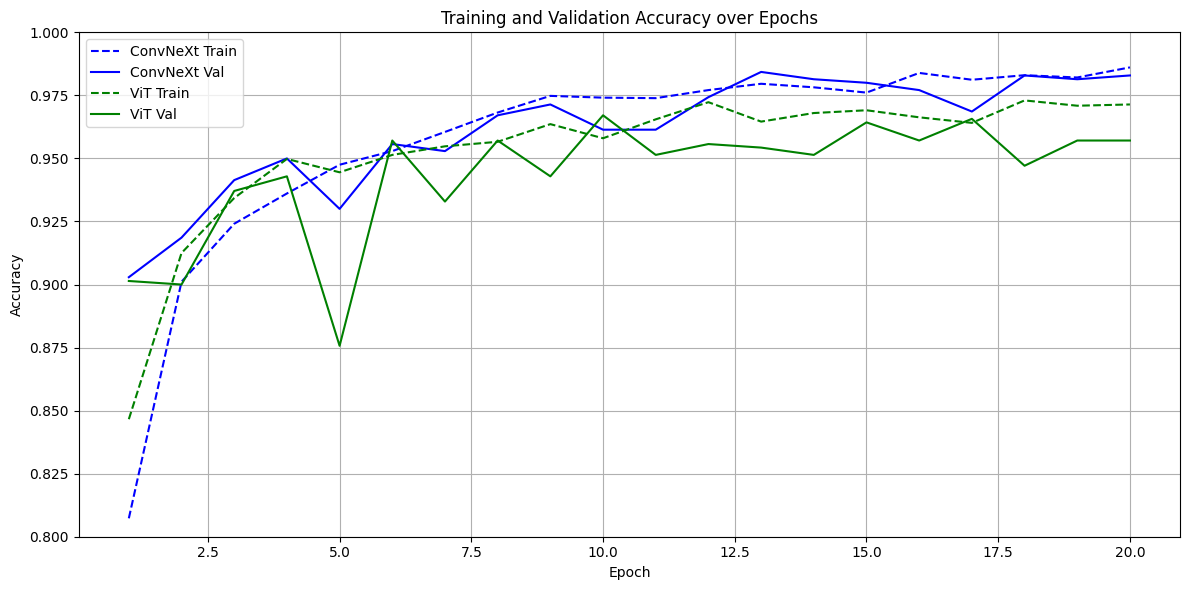

In [15]:
import matplotlib.pyplot as plt

# ConvNeXt accuracies
convnext_train_acc = [
    0.8073, 0.9011, 0.9241, 0.9361, 0.9475, 0.9529, 0.9605, 0.9682, 0.9748, 0.9741,
    0.9739, 0.9771, 0.9796, 0.9782, 0.9761, 0.9839, 0.9812, 0.9830, 0.9821, 0.9861
]
convnext_val_acc = [
    0.9029, 0.9186, 0.9414, 0.9500, 0.9300, 0.9557, 0.9529, 0.9671, 0.9714, 0.9614,
    0.9614, 0.9743, 0.9843, 0.9814, 0.9800, 0.9771, 0.9686, 0.9829, 0.9814, 0.9829
]

# ViT accuracies
vit_train_acc = [
    0.8466, 0.9125, 0.9343, 0.9498, 0.9445, 0.9514, 0.9548, 0.9566, 0.9636, 0.9580,
    0.9655, 0.9723, 0.9646, 0.9680, 0.9691, 0.9663, 0.9641, 0.9730, 0.9709, 0.9714
]
vit_val_acc = [
    0.9014, 0.9000, 0.9371, 0.9429, 0.8757, 0.9571, 0.9329, 0.9571, 0.9429, 0.9671,
    0.9514, 0.9557, 0.9543, 0.9514, 0.9643, 0.9571, 0.9657, 0.9471, 0.9571, 0.9571
]

# Epoch range
epochs = range(1, 21)

# Plotting
plt.figure(figsize=(12, 6))

# ConvNeXt
plt.plot(epochs, convnext_train_acc, 'b--', label='ConvNeXt Train')
plt.plot(epochs, convnext_val_acc, 'b-', label='ConvNeXt Val')

# ViT
plt.plot(epochs, vit_train_acc, 'g--', label='ViT Train')
plt.plot(epochs, vit_val_acc, 'g-', label='ViT Val')

plt.title("Training and Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.80, 1.00)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# Save ConvNeXt model
torch.save(convnext_model.state_dict(), "convnext_tb.pth")

# Save ViT model
torch.save(vit_model.state_dict(), "vit_tb.pth")


In [17]:
# ConvNeXt
convnext_model = models.convnext_tiny(weights=None)
convnext_model.classifier[2] = nn.Linear(convnext_model.classifier[2].in_features, 2)
convnext_model.load_state_dict(torch.load("convnext_tb.pth"))
convnext_model.to(device)
convnext_model.eval()

# ViT
vit_model = models.vit_b_16(weights=None)
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, 2)
vit_model.load_state_dict(torch.load("vit_tb.pth"))
vit_model.to(device)
vit_model.eval()


<ipython-input-17-3e1930b72967>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  convnext_model.load_state_dict(torch.load("convnext_tb.pth"))
<ipython-input-17-3e1930b72967

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [18]:
torch.save(convnext_model.state_dict(), "/kaggle/working/convnext_tb.pth")
torch.save(vit_model.state_dict(), "/kaggle/working/vit_tb.pth")


In [19]:
import zipfile

with zipfile.ZipFile("/kaggle/working/tb_ensemble_models.zip", "w") as zipf:
    zipf.write("/kaggle/working/convnext_tb.pth")
    zipf.write("/kaggle/working/vit_tb.pth")


In [20]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [21]:
def ensemble_forward(input_tensor):

    convnext_model.cpu()
    vit_model.cpu()

    out1 = torch.softmax(convnext_model(input_tensor), dim=1)
    out2 = torch.softmax(vit_model(input_tensor), dim=1)

    return (out1 + out2) / 2

In [23]:
from PIL import Image

class_names = ["Normal","Tuberculosis"]

def ensemble_predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0)

    probs = ensemble_forward(input_tensor)

    confidence, pred_class = torch.max(probs,1)

    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100,2)

    print("Prediction:", prediction)
    print("Confidence Score:", confidence,"%")

    return input_tensor, pred_class.item(), prediction

In [24]:
!pip install captum shap lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.8 MB/s eta 0:00:0000:0100:01


In [25]:
from captum.attr import IntegratedGradients
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np

In [27]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def captum_explain(image_path):

    input_tensor, target, prediction = ensemble_predict_image(image_path)

    # Move models and tensor to CPU to avoid GPU memory error
    convnext_model.cpu()
    vit_model.cpu()
    input_tensor = input_tensor.cpu()

    input_tensor.requires_grad = True

    ig = IntegratedGradients(ensemble_forward)

    attributions = ig.attribute(input_tensor, target=target)

    attr = attributions.squeeze().permute(1,2,0).detach().numpy()

    # Load original image
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))
    image_np = np.array(image)

    heatmap = attr.mean(axis=2)

    plt.figure(figsize=(6,6))
    plt.imshow(image_np)
    plt.imshow(heatmap, cmap="hot", alpha=0.5)
    plt.title("Captum Explanation (Integrated Gradients)")
    plt.axis("off")

    print("\nCaptum Explanation:")

    if prediction == "Tuberculosis":
        print("Captum highlights the pixels in the chest X-ray that most influenced the ensemble model toward a Tuberculosis prediction. The brighter regions correspond to lung areas where abnormal patterns or opacity were detected.")
    else:
        print("Captum highlights regions that supported the ensemble model's Normal lung classification. These regions represent healthy lung structures without patterns associated with tuberculosis.")

    # Move models back to GPU after explanation
    convnext_model.to(device)
    vit_model.to(device)

In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def shap_explain(image_path):

    input_tensor, target, prediction = ensemble_predict_image(image_path)

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))
    image_np = np.array(image)

    def shap_predict(images):

        images = torch.tensor(images).permute(0,3,1,2).float()

        probs = ensemble_forward(images)

        return probs.detach().cpu().numpy()

    masker = shap.maskers.Image("blur(32,32)", image_np.shape)

    explainer = shap.Explainer(shap_predict, masker)

    shap_values = explainer(
        image_np[np.newaxis,...],
        max_evals=500,
        batch_size=50
    )

    shap.image_plot(shap_values)

    print("\nSHAP Explanation:")

    if prediction == "Tuberculosis":
        print("SHAP highlights regions that increased the probability of Tuberculosis in the ensemble model.")
    else:
        print("SHAP highlights regions supporting the Normal lung classification.")

In [29]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

explainer = lime_image.LimeImageExplainer()

def lime_explain(image_path):

    # Get prediction and confidence
    input_tensor, target, prediction = ensemble_predict_image(image_path)

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224,224))
    image_np = np.array(image)

    def lime_predict(images):

        images = torch.tensor(images).permute(0,3,1,2).float()

        probs = ensemble_forward(images)

        return probs.detach().cpu().numpy()

    explanation = explainer.explain_instance(
        image_np,
        lime_predict,
        top_labels=2,
        hide_color=0,
        num_samples=1500
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME Explanation")
    plt.axis("off")

    print("\nLIME Explanation:")

    if prediction == "Tuberculosis":
        print("LIME divides the chest X-ray into superpixel segments and highlights the regions that most influenced the ensemble model toward a Tuberculosis prediction.")
    else:
        print("LIME highlights the superpixel regions that supported the ensemble model's Normal lung classification.")

In [30]:
import torch
torch.cuda.empty_cache()

Prediction: Normal
Confidence Score: 99.12 %

Captum Explanation:
Captum highlights regions that supported the ensemble model's Normal lung classification. These regions represent healthy lung structures without patterns associated with tuberculosis.
Prediction: Normal
Confidence Score: 99.12 %


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:51, 111.91s/it]              


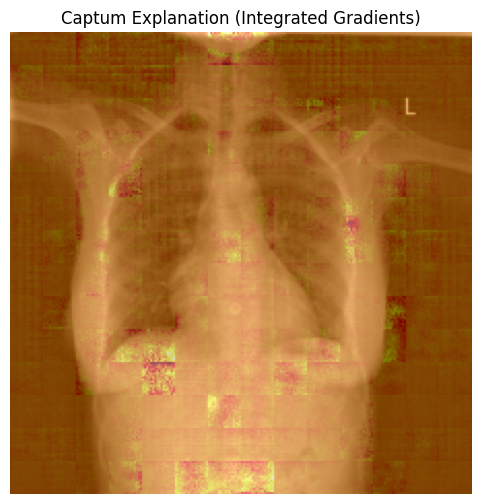

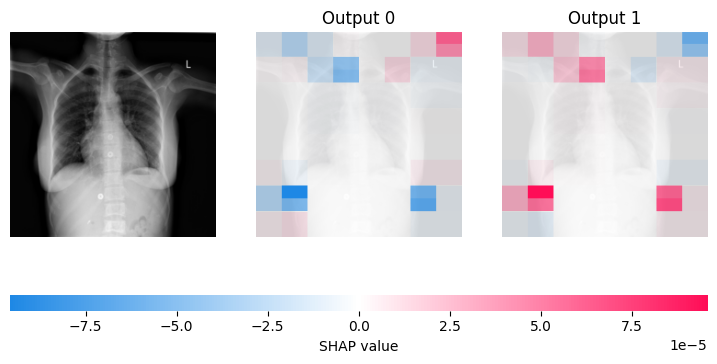


SHAP Explanation:
SHAP highlights regions supporting the Normal lung classification.
Prediction: Normal
Confidence Score: 99.12 %


  0%|          | 0/1500 [00:00<?, ?it/s]


LIME Explanation:
LIME highlights the superpixel regions that supported the ensemble model's Normal lung classification.


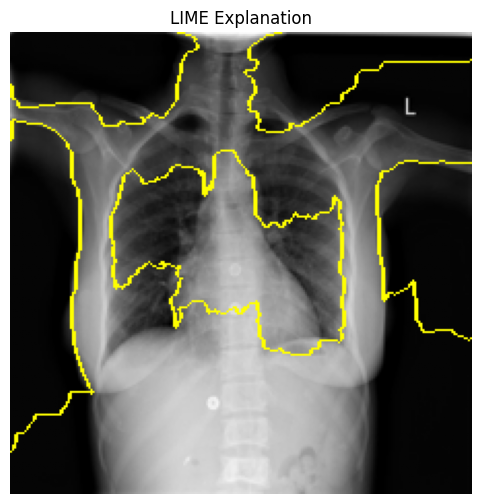

In [31]:
image_path = "/kaggle/input/tuberculosisdaata/TB_Data/Test/Normal/Normal-1002.png"

captum_explain(image_path)

shap_explain(image_path)

lime_explain(image_path)

Prediction: Tuberculosis
Confidence Score: 99.9 %

Captum Explanation:
Captum highlights the pixels in the chest X-ray that most influenced the ensemble model toward a Tuberculosis prediction. The brighter regions correspond to lung areas where abnormal patterns or opacity were detected.
Prediction: Tuberculosis
Confidence Score: 99.9 %


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:36, 96.08s/it]               


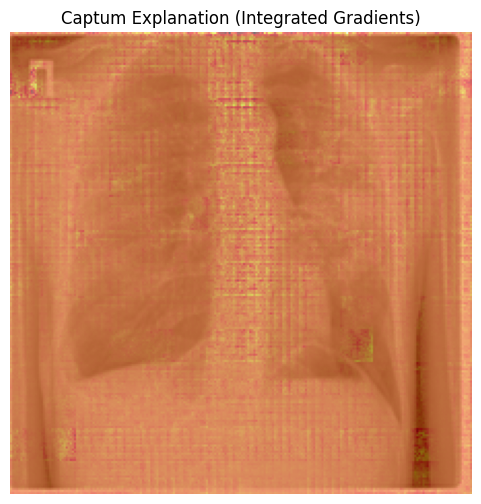

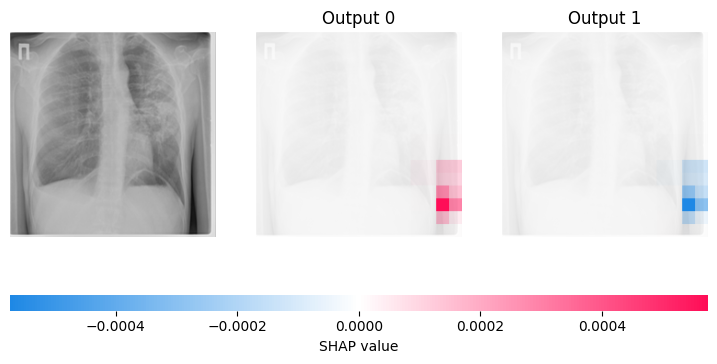


SHAP Explanation:
SHAP highlights regions that increased the probability of Tuberculosis in the ensemble model.
Prediction: Tuberculosis
Confidence Score: 99.9 %


  0%|          | 0/1500 [00:00<?, ?it/s]


LIME Explanation:
LIME divides the chest X-ray into superpixel segments and highlights the regions that most influenced the ensemble model toward a Tuberculosis prediction.


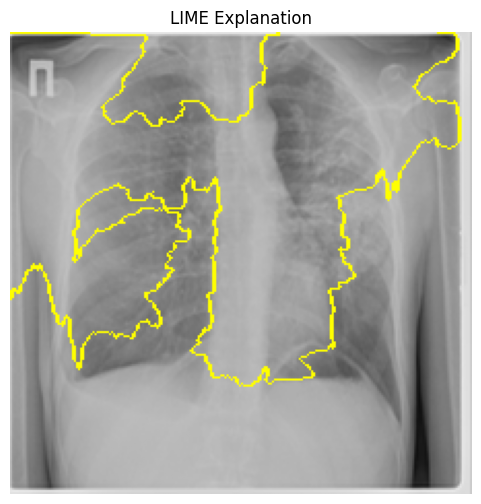

In [32]:
image_path = "/kaggle/input/tuberculosisdaata/TB_Data/Test/Tuberculosis/Tuberculosis-151.png"
captum_explain(image_path)

shap_explain(image_path)

lime_explain(image_path)

In [34]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=4f1aa7d3333083b1ceb4f5e4f524d71b8a68aaba1ebdc7b5ed5b2e4a1201bb0c
  Stored in directory: /root/.cache/pip/wheels/3d/b6/be/e13cccebb2aa8855f678b02ad449e803de1dfbe75853c34b3e
Successfully built grad-cam


In [35]:
from pytorch_grad_cam import GradCAMPlusPlus
import cv2

def gradcamplusplus_ensemble(model, image_path):

    model.eval()
    model.cpu()

    image = Image.open(image_path).convert("RGB").resize((224,224))
    input_tensor = transform(image).unsqueeze(0)

    # ⚠️ Use ConvNeXt inside ensemble
    target_layer = convnext_model.features[-1]

    cam = GradCAMPlusPlus(
        model=convnext_model,
        target_layers=[target_layer]
    )

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    cam = cv2.resize(grayscale_cam, (224,224))

    # Prediction (ENSEMBLE)
    probs = ensemble_forward(input_tensor)
    confidence, pred_class = torch.max(probs, 1)

    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100, 2)

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title("Grad-CAM++ (Ensemble - ConvNeXt)")
    plt.axis("off")

    print("\nPrediction:", prediction)
    print("Confidence Score:", confidence, "%")

    print("\nGrad-CAM++ Explanation:")
    print("Uses ConvNeXt part of ensemble to localize important regions.")

In [36]:
def smoothgrad_ensemble(image_path, samples=20, noise_level=0.1):

    image = Image.open(image_path).convert("RGB").resize((224,224))
    input_tensor = transform(image).unsqueeze(0)

    smooth_grad = torch.zeros_like(input_tensor)

    for _ in range(samples):

        noise = torch.randn_like(input_tensor) * noise_level
        noisy_input = (input_tensor + noise).clone().detach().requires_grad_(True)

        output = ensemble_forward(noisy_input)
        probs = torch.softmax(output, dim=1)

        pred_class = probs.argmax()

        convnext_model.zero_grad()
        vit_model.zero_grad()

        output[0, pred_class].backward()

        smooth_grad += noisy_input.grad

    smooth_grad /= samples

    grad = smooth_grad.squeeze().permute(1,2,0).detach().numpy()
    heatmap = grad.mean(axis=2)

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Prediction
    probs = ensemble_forward(input_tensor)
    confidence, pred_class = torch.max(probs, 1)

    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100, 2)

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(heatmap, cmap='hot', alpha=0.5)
    plt.title("SmoothGrad (Ensemble)")
    plt.axis("off")

    print("\nPrediction:", prediction)
    print("Confidence Score:", confidence, "%")

    print("\nSmoothGrad Explanation:")
    print("Highlights pixel-level importance from ensemble prediction.")

In [37]:
def occlusion_ensemble(image_path, patch_size=32):

    image = Image.open(image_path).convert("RGB").resize((224,224))
    input_tensor = transform(image).unsqueeze(0)

    # Original prediction
    probs = ensemble_forward(input_tensor)
    confidence, pred_class = torch.max(probs, 1)

    prediction = class_names[pred_class.item()]
    confidence = round(confidence.item()*100, 2)

    heatmap = np.zeros((224,224))

    for i in range(0, 224, patch_size):
        for j in range(0, 224, patch_size):

            occluded = input_tensor.clone()
            occluded[:, :, i:i+patch_size, j:j+patch_size] = 0

            out = ensemble_forward(occluded)
            prob = torch.softmax(out, dim=1)[0, pred_class].item()

            importance = confidence/100 - prob
            heatmap[i:i+patch_size, j:j+patch_size] = importance

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title("Occlusion (Ensemble)")
    plt.axis("off")

    print("\nPrediction:", prediction)
    print("Confidence Score:", confidence, "%")

    print("\nOcclusion Explanation:")
    print("Shows region importance using ensemble predictions.")

In [38]:
image_path = "/kaggle/input/tuberculosisdaata/TB_Data/Test/Tuberculosis/Tuberculosis-117.png"



Prediction: Tuberculosis
Confidence Score: 99.75 %

Grad-CAM++ Explanation:
Uses ConvNeXt part of ensemble to localize important regions.


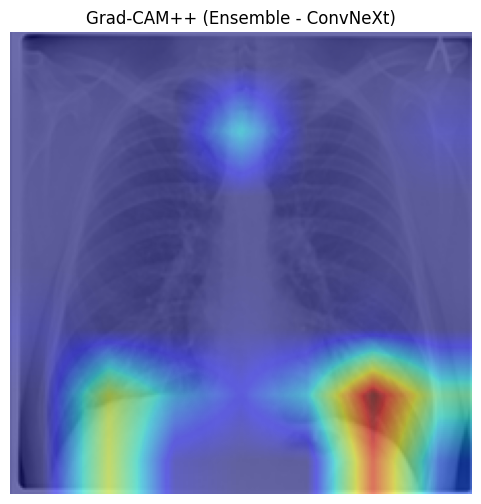

In [39]:
gradcamplusplus_ensemble(convnext_model, image_path)


Prediction: Tuberculosis
Confidence Score: 99.75 %

SmoothGrad Explanation:
Highlights pixel-level importance from ensemble prediction.


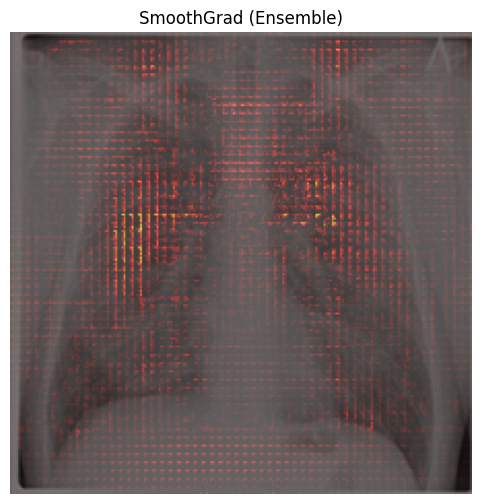

In [40]:
smoothgrad_ensemble(image_path)


Prediction: Tuberculosis
Confidence Score: 99.75 %

Occlusion Explanation:
Shows region importance using ensemble predictions.


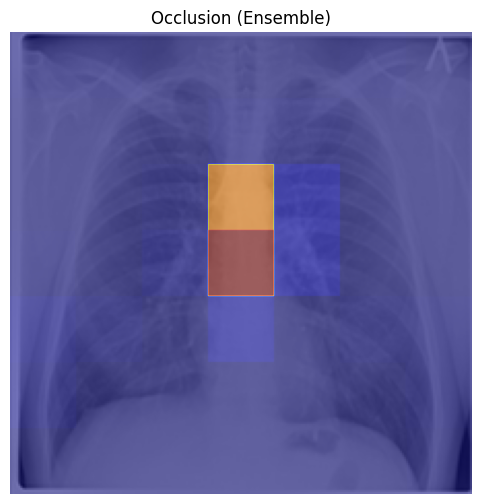

In [41]:
occlusion_ensemble(image_path)

In [43]:
image_path = "/kaggle/input/tuberculosisdaata/TB_Data/Test/Normal/Normal-1009.png"



Prediction: Normal
Confidence Score: 99.32 %

Grad-CAM++ Explanation:
Uses ConvNeXt part of ensemble to localize important regions.


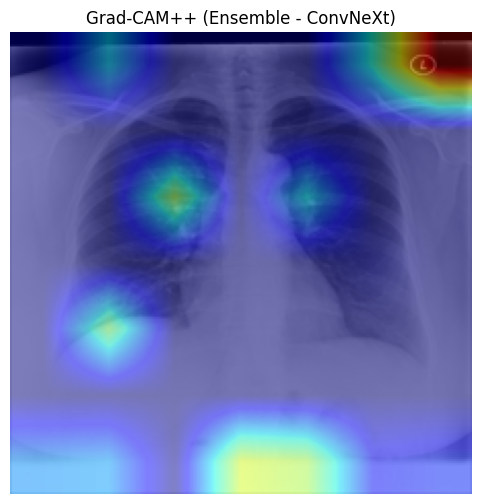

In [44]:
gradcamplusplus_ensemble(convnext_model, image_path)


Prediction: Normal
Confidence Score: 99.32 %

SmoothGrad Explanation:
Highlights pixel-level importance from ensemble prediction.


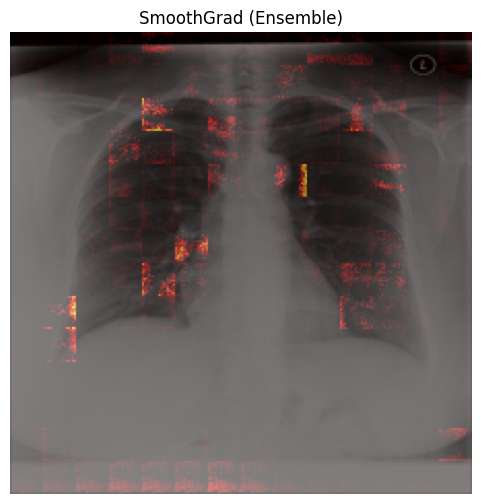

In [45]:
smoothgrad_ensemble(image_path)


Prediction: Normal
Confidence Score: 99.32 %

Occlusion Explanation:
Shows region importance using ensemble predictions.


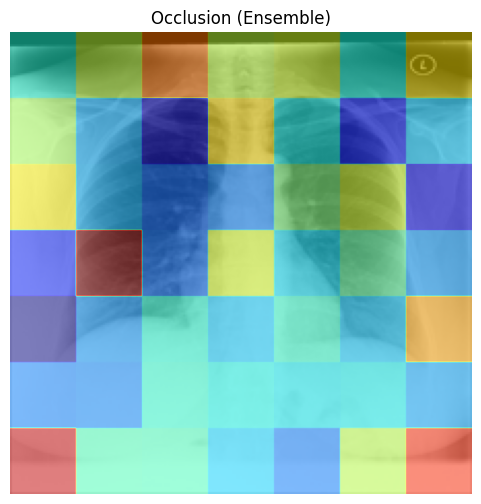

In [46]:
occlusion_ensemble(image_path)

In [48]:
ensemble_info = {
    "model1": "convnext",
    "model2": "vit",
    "method": "soft_voting"
}

torch.save(ensemble_info, "/kaggle/working/ensemble_config.pth")

In [49]:
import zipfile

with zipfile.ZipFile("/kaggle/working/tb_ensemble_models.zip", "w") as zipf:
    zipf.write("/kaggle/working/convnext_tb.pth")
    zipf.write("/kaggle/working/vit_tb.pth")